# SVD

In [2]:
from matplotlib.image import imread
import matplotlib.pyplot as plt
import numpy as np
import os
plt.rcParams['figure.figsize'] = [16,8]

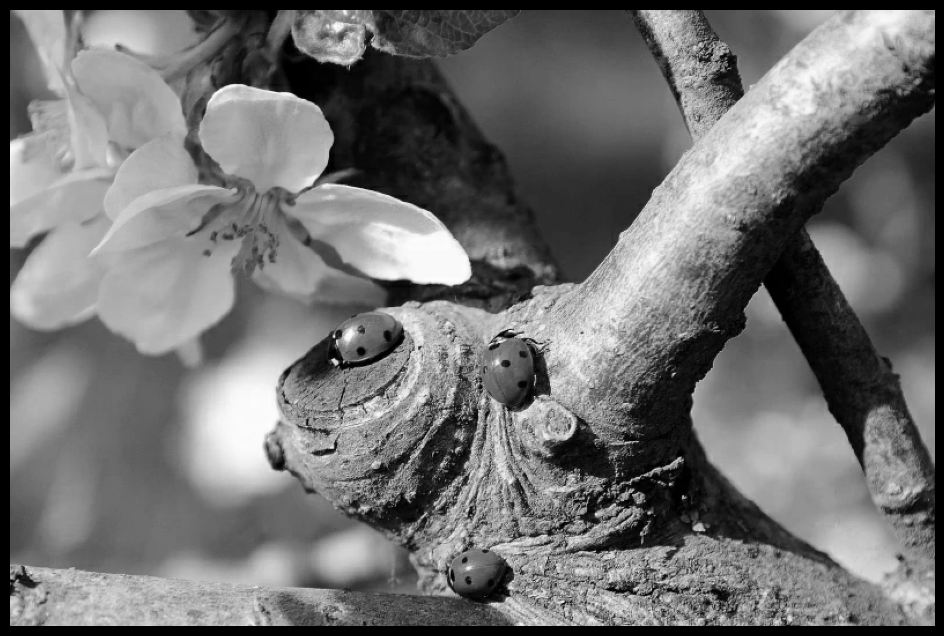

In [3]:
A = imread('14.webp')
X = np.mean(A,-1) # convert RGB to grayscale

#img = plt.imshow(256-X)
img = plt.imshow(X)
img.set_cmap('gray')
plt.axis('off')
plt.show()

Wymagana liczba wartości singularnych: 235
Zachowana energia: 90.08%


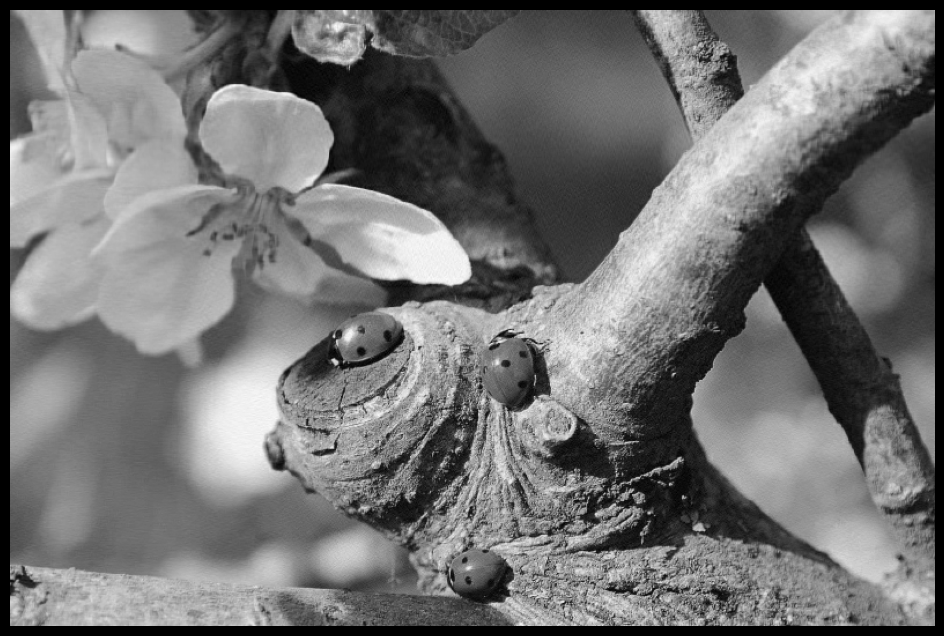

In [5]:
U, S, VT = np.linalg.svd(X, full_matrices=False)
energia_calkowita = np.sum(S)
energia_skumulowana = np.cumsum(S) / energia_calkowita
r_90 = np.argmax(energia_skumulowana >= 0.90) + 1

print(f"Wymagana liczba wartości singularnych: {r_90}")
print(f"Zachowana energia: {energia_skumulowana[r_90-1]*100:.2f}%")

S = np.diag(S)
Xapprox = U[:, :r_90] @ S[0:r_90, :r_90] @ VT[:r_90, :]

plt.figure()
img = plt.imshow(Xapprox)
img.set_cmap('gray')
plt.axis('off')
plt.show()

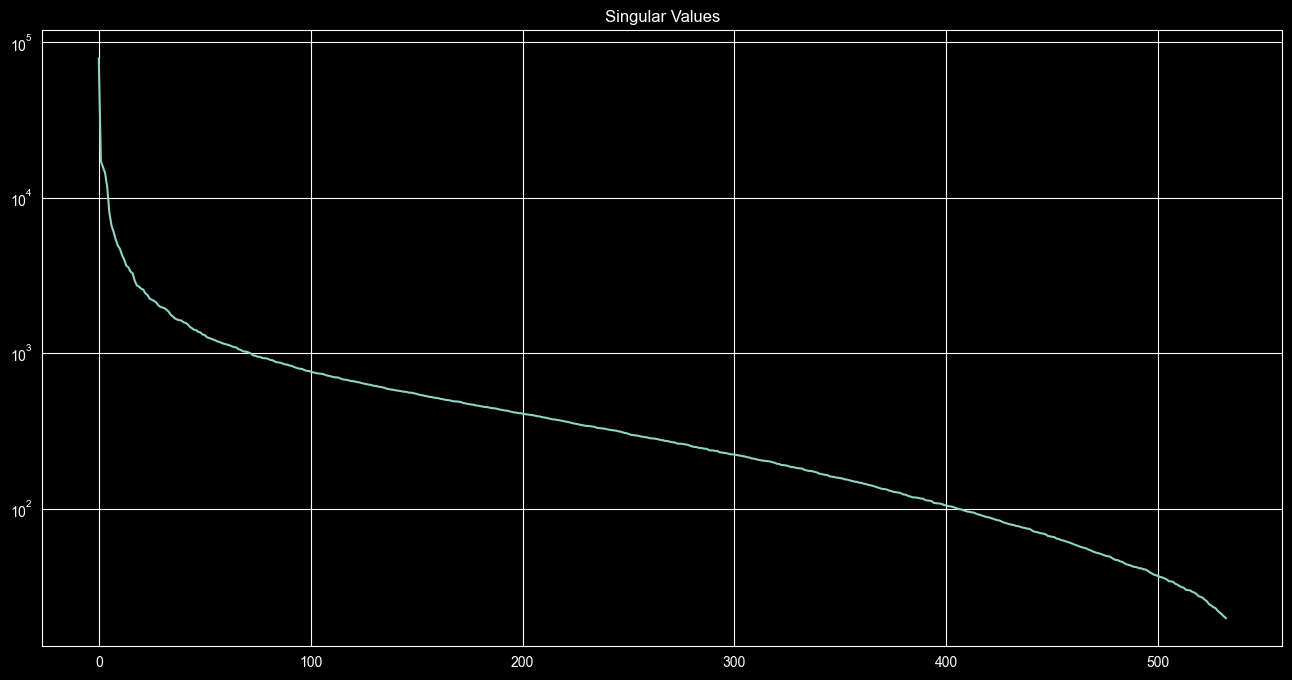

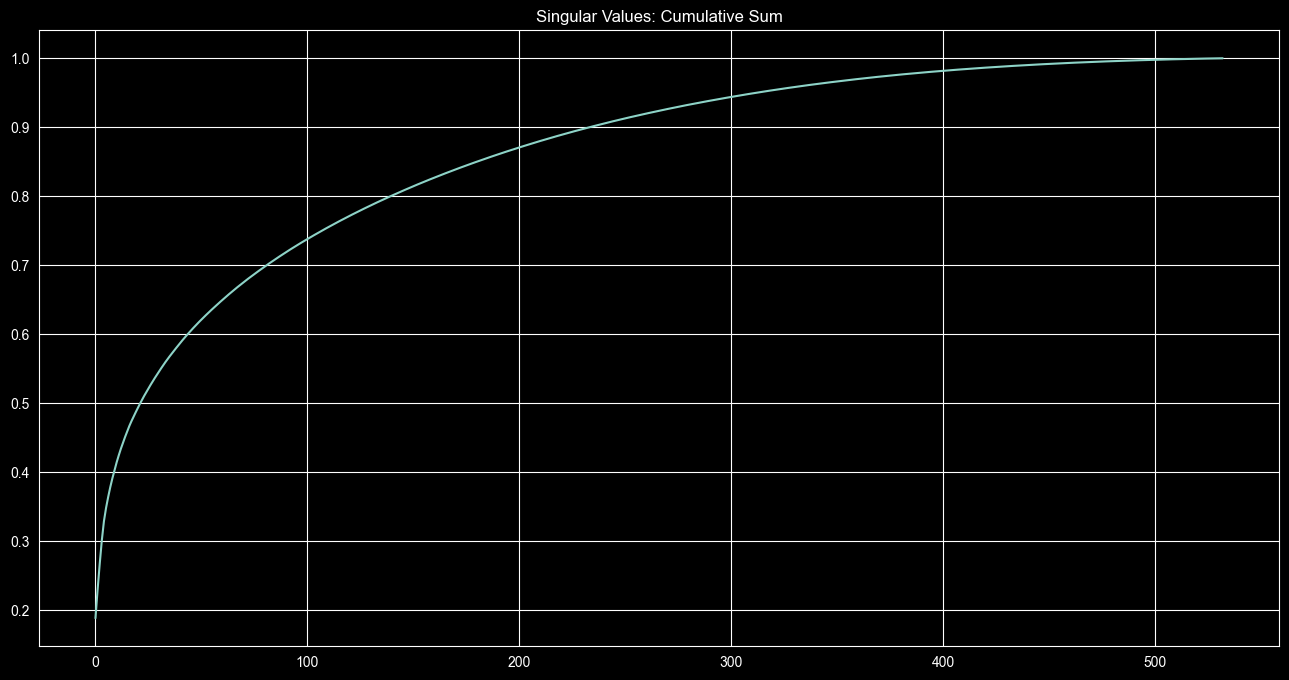

In [39]:
plt.figure(1)
plt.semilogy(np.diag(S))
plt.title('Singular Values')
plt.show()

plt.figure(2)
plt.plot(np.cumsum(np.diag(S))/np.sum(np.diag(S)))
plt.title('Singular Values: Cumulative Sum')
plt.show()